In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import norm

In [2]:
def load_npe_replicate(setting, replicate_idx):
    """Load NPE posterior means and stds for a given setting and replicate."""
    npe_data = torch.load(
        f"npe/setting{setting}/npe_credible_intervals_setting{setting}_{replicate_idx}.pt",
        weights_only=False,
    )
    confidence_levels = npe_data["confidence_levels"].numpy()
    # Recover Gaussian std from the 95% CI: ci_upper = mean + q * std, q = Phi^-1(0.975)
    k = 18
    q = norm.ppf(1 - (1 - confidence_levels[k]) / 2)

    shear1_mean = npe_data["shear1_posteriormean"].numpy()
    shear2_mean = npe_data["shear2_posteriormean"].numpy()
    shear1_std = (npe_data["shear1_ci_upper"][:, k].numpy() - shear1_mean) / q
    shear2_std = (npe_data["shear2_ci_upper"][:, k].numpy() - shear2_mean) / q

    return {
        "shear1_true": npe_data["shear1_true"].numpy(),
        "shear2_true": npe_data["shear2_true"].numpy(),
        "shear1_mean": shear1_mean,
        "shear2_mean": shear2_mean,
        "shear1_std": shear1_std,
        "shear2_std": shear2_std,
    }


def load_anacal_replicate(setting, replicate_idx):
    """Load per-sample AnaCal shear estimates and truth for a given setting and replicate."""
    anacal_data = torch.load(
        f"anacal/setting{setting}/anacal_results_setting{setting}_{replicate_idx}.pt",
        weights_only=False,
    )
    e1_avg = anacal_data["e1_sum"] / anacal_data["num_detections"]
    e2_avg = anacal_data["e2_sum"] / anacal_data["num_detections"]
    R1 = anacal_data["e1g1_sum"].sum() / anacal_data["num_detections"].sum()
    R2 = anacal_data["e2g2_sum"].sum() / anacal_data["num_detections"].sum()
    return {
        "shear1_true": np.asarray(anacal_data["shear_1"]),
        "shear2_true": np.asarray(anacal_data["shear_2"]),
        "shear1": np.asarray(e1_avg / R1),
        "shear2": np.asarray(e2_avg / R2),
    }

In [3]:
def plot_posterior_densities(npe, anacal, indices, setting, save_path=None):
    """Plot NPE posterior densities with truth and (optional) AnaCal overlays.

    Layout: 2 rows (gamma_1 on top, gamma_2 on bottom) x len(indices) columns.
    If anacal is None, the AnaCal vertical line is omitted.
    """
    n = len(indices)
    fig, ax = plt.subplots(2, n, figsize=(3.5 * n, 6))
    if n == 1:
        ax = ax[:, None]

    fontsize = 14
    ticklabelsize = 12
    legendlabelsize = 10
    supylabelsize = 18
    titlepad = 24
    npe_color = "#1c692b"
    anacal_color = "#c231c2"
    truth_color = "black"
    axmin, axmax = -0.04, 0.04
    x = np.linspace(axmin, axmax, 500)

    components = [
        ("shear1", r"$\gamma_1$"),
        ("shear2", r"$\gamma_2$"),
    ]

    for row, (comp, label) in enumerate(components):
        mean_key = f"{comp}_mean"
        std_key = f"{comp}_std"
        truth_key = f"{comp}_true"
        for col, idx in enumerate(indices):
            mu = npe[mean_key][idx]
            sigma = npe[std_key][idx]
            pdf = norm.pdf(x, loc=mu, scale=sigma)

            a = ax[row, col]
            a.plot(x, pdf, color=npe_color, label="NPE")
            if anacal is not None:
                a.axvline(anacal[comp][idx], color=anacal_color, linestyle="solid", label="AnaCal")
            a.axvline(npe[truth_key][idx], color=truth_color, linestyle="dashed", label="Truth")
            a.set_xlim(axmin, axmax)
            a.set_xlabel(label, fontsize=fontsize)
            a.tick_params(axis="both", which="major", labelsize=ticklabelsize)
            a.spines[["top", "right"]].set_visible(False)
            if col == 0:
                a.set_ylabel("density", fontsize=fontsize)
            if row == 0:
                a.set_title(f"image {col + 1}", fontsize=fontsize, pad=titlepad)

    ax[0, 0].legend(prop={"size": legendlabelsize}, loc="upper left")

    fig.tight_layout()
    fig.supylabel(f"setting {setting}", fontsize=supylabelsize, fontweight="bold", x=-0.02)

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=600,
            transparent=True,
            bbox_inches="tight",
            pad_inches=0.1,
        )

### **Setting 1**

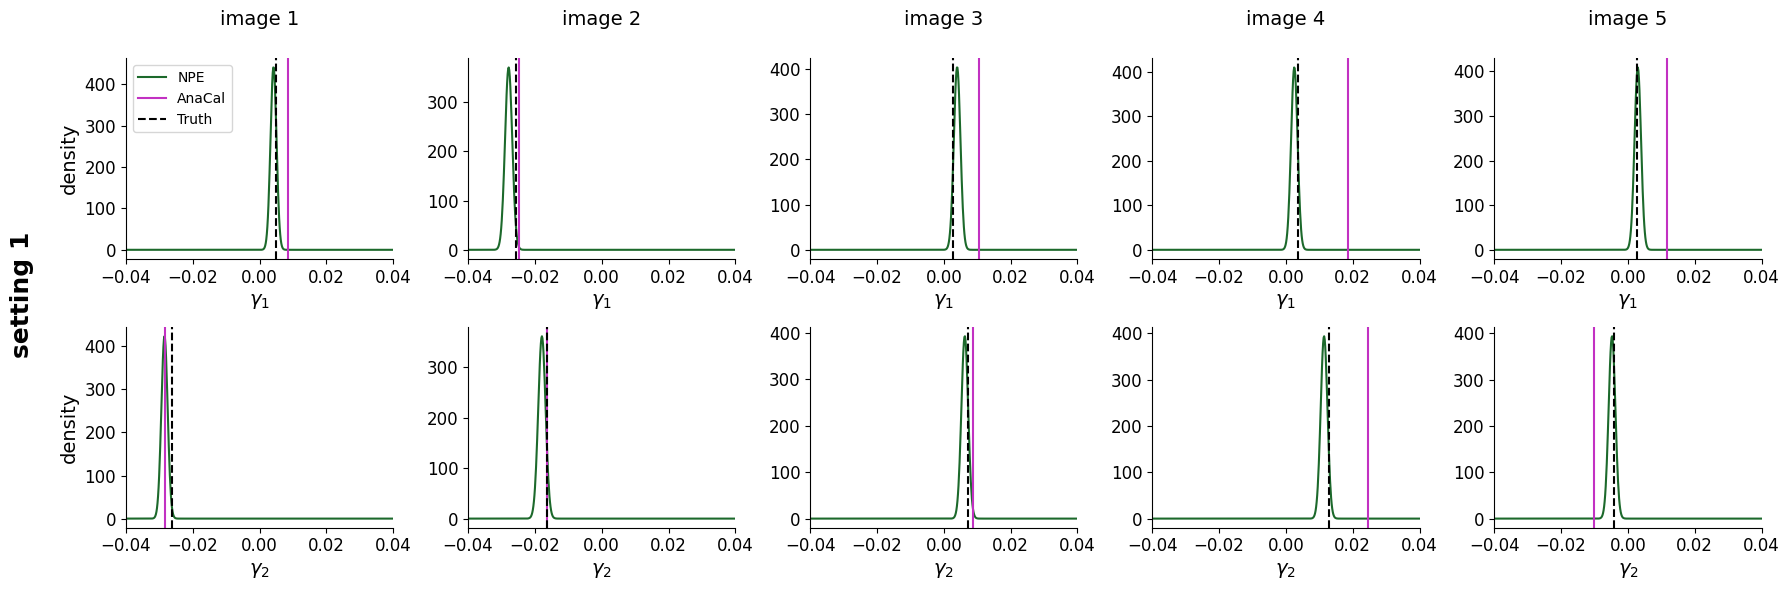

In [4]:
setting = 1
npe1 = load_npe_replicate(setting, 1)
anacal1 = load_anacal_replicate(setting, 1)

assert np.allclose(npe1["shear1_true"], anacal1["shear1_true"]), "NPE and AnaCal shear_1 truths must match"
assert np.allclose(npe1["shear2_true"], anacal1["shear2_true"]), "NPE and AnaCal shear_2 truths must match"

rng = np.random.default_rng(0)
indices1 = rng.choice(len(npe1["shear1_true"]), size=5, replace=False)

plot_posterior_densities(npe1, anacal1, indices1, setting=setting, save_path=f"figures/posterior_densities_setting{setting}.png")

### **Setting 2**

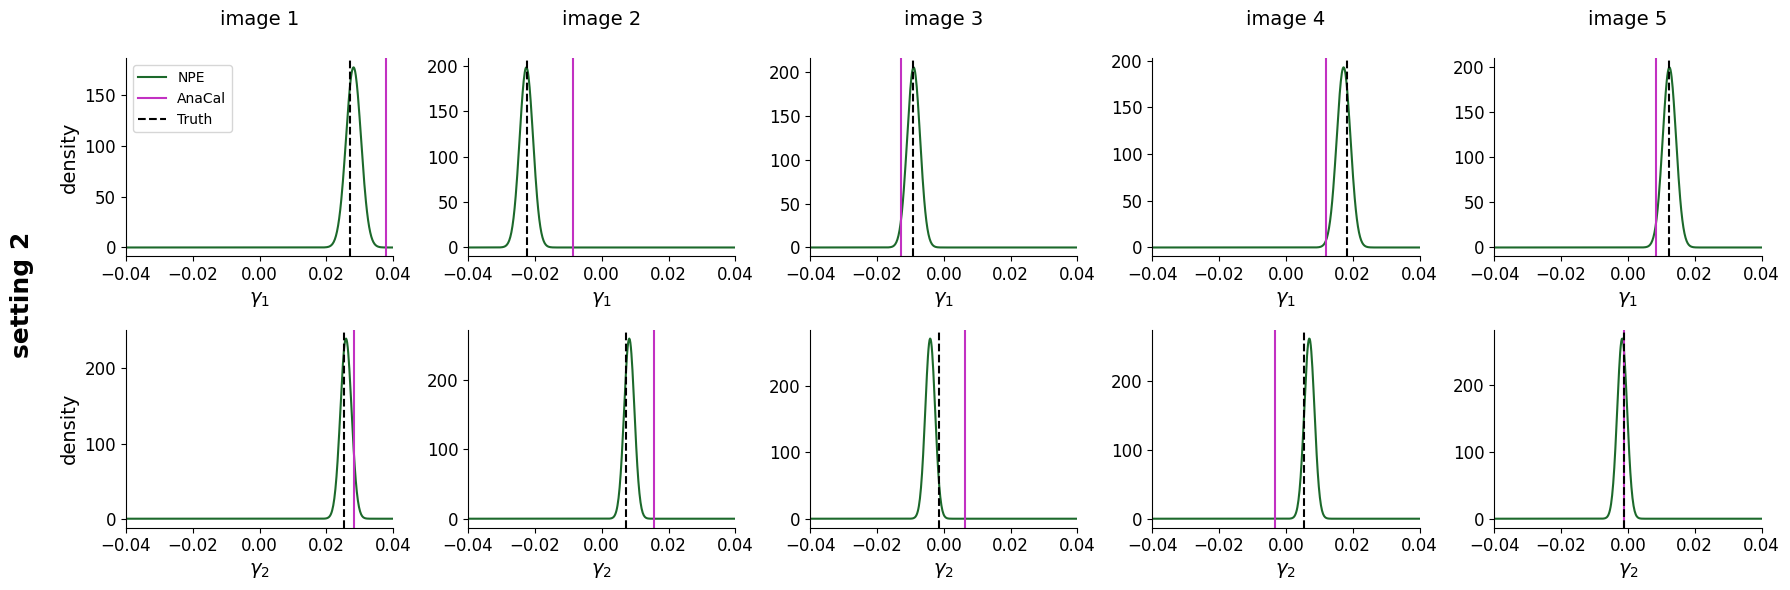

In [5]:
setting = 2
npe2 = load_npe_replicate(setting, 1)
anacal2 = load_anacal_replicate(setting, 1)

assert np.allclose(npe2["shear1_true"], anacal2["shear1_true"]), "NPE and AnaCal shear_1 truths must match"
assert np.allclose(npe2["shear2_true"], anacal2["shear2_true"]), "NPE and AnaCal shear_2 truths must match"

rng = np.random.default_rng(0)
indices2 = rng.choice(len(npe2["shear1_true"]), size=5, replace=False)

plot_posterior_densities(npe2, anacal2, indices2, setting=setting, save_path=f"figures/posterior_densities_setting{setting}.png")

### **Setting 3**

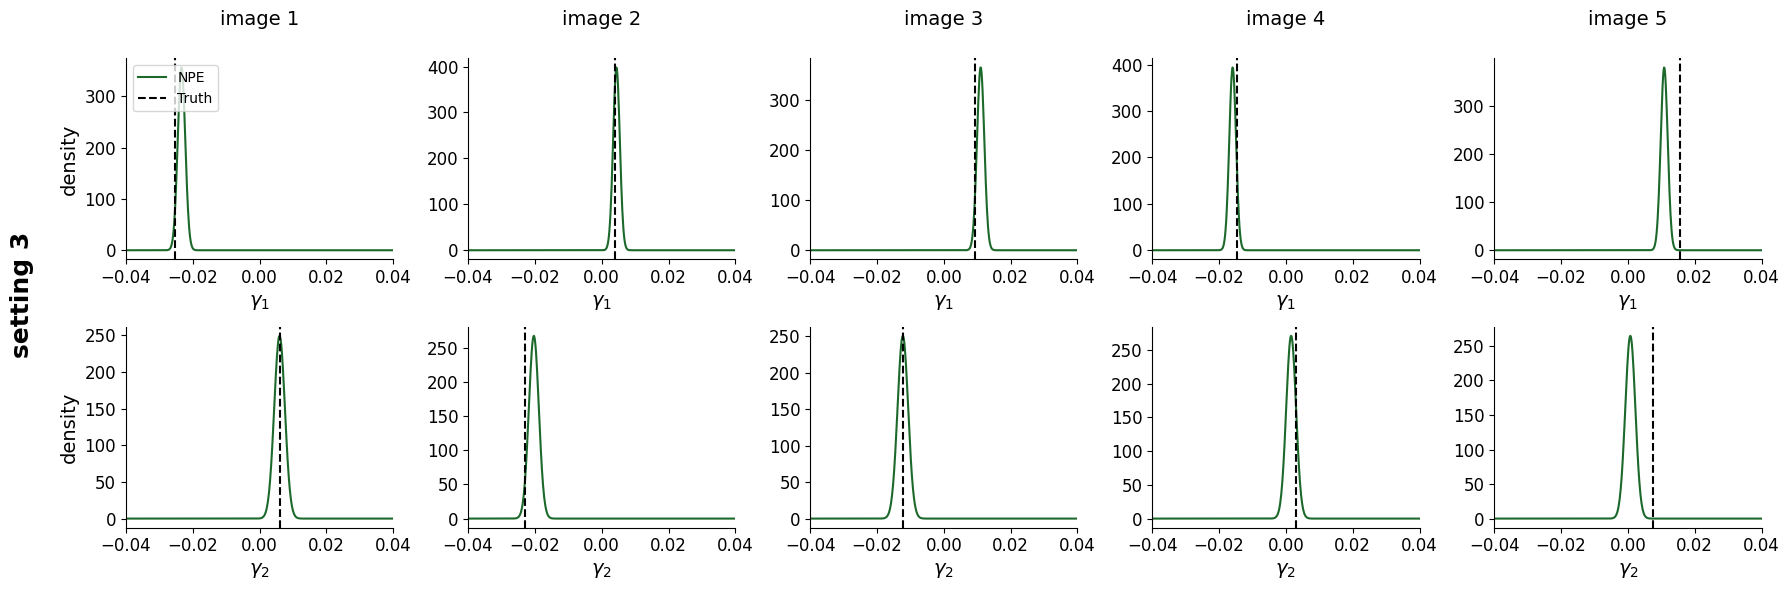

In [6]:
setting = 3
npe3 = load_npe_replicate(setting, 1)

rng = np.random.default_rng(0)
indices3 = rng.choice(len(npe3["shear1_true"]), size=5, replace=False)

plot_posterior_densities(npe3, None, indices3, setting=setting, save_path=f"figures/posterior_densities_setting{setting}.png")

### **Setting 4**

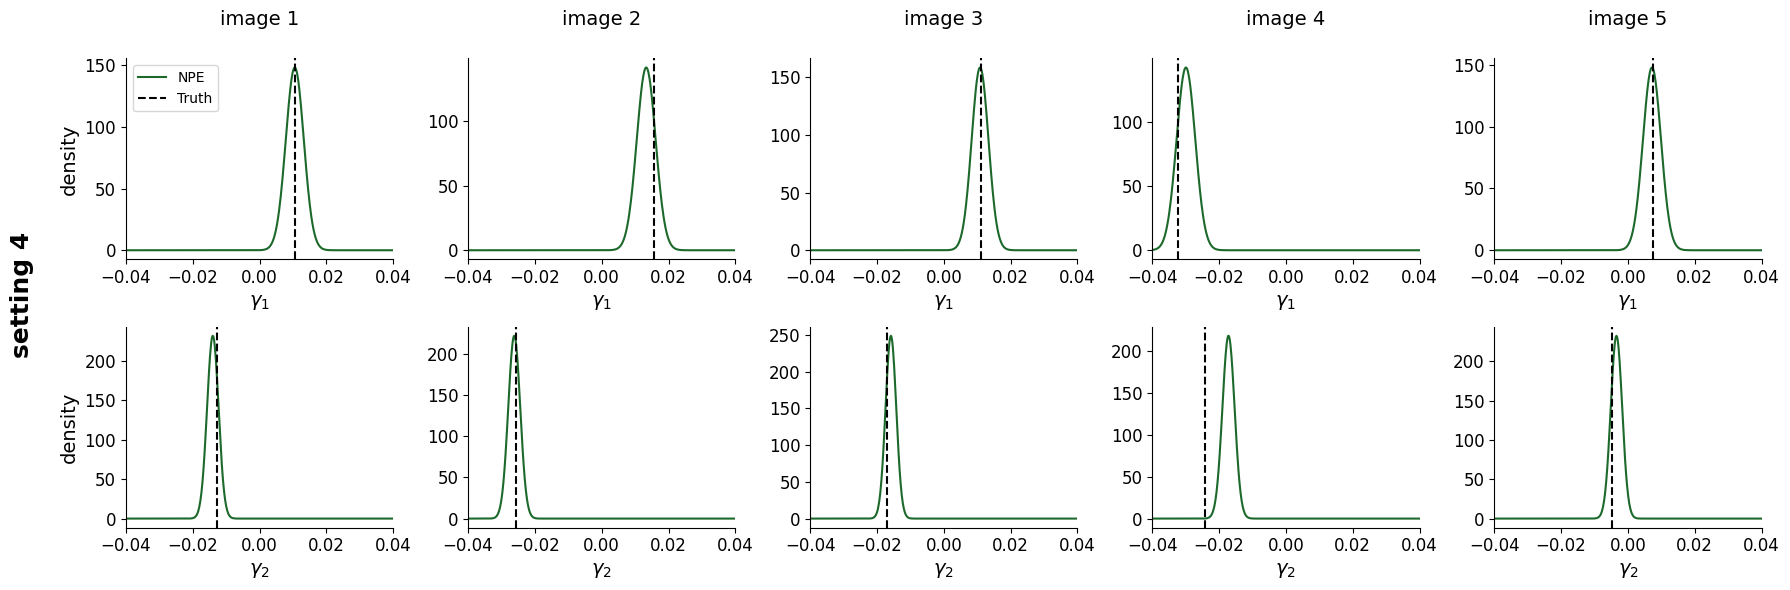

In [7]:
setting = 4
npe4 = load_npe_replicate(setting, 1)

rng = np.random.default_rng(0)
indices4 = rng.choice(len(npe4["shear1_true"]), size=5, replace=False)

plot_posterior_densities(npe4, None, indices4, setting=setting, save_path=f"figures/posterior_densities_setting{setting}.png")

### **Setting 5**

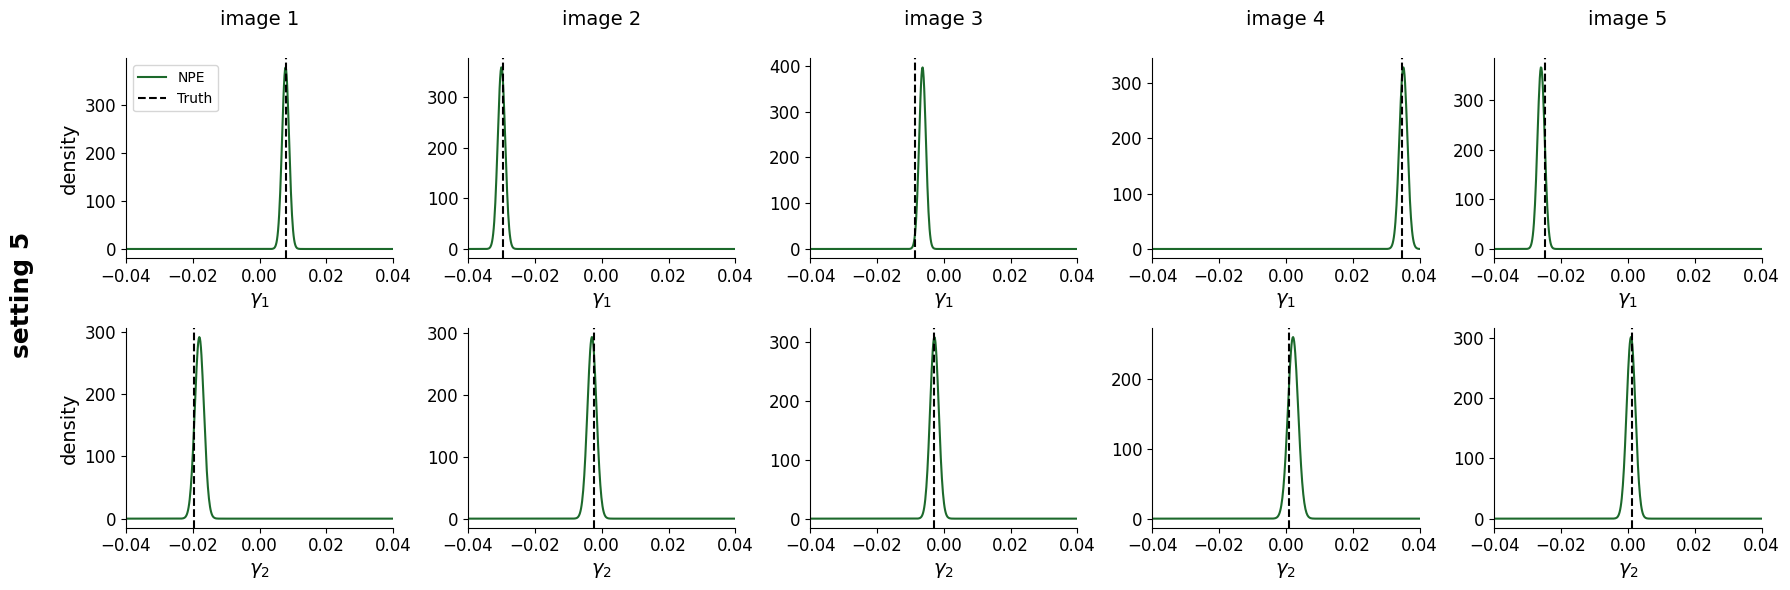

In [8]:
setting = 5
npe5 = load_npe_replicate(setting, 1)

rng = np.random.default_rng(0)
indices5 = rng.choice(len(npe5["shear1_true"]), size=5, replace=False)

plot_posterior_densities(npe5, None, indices5, setting=setting, save_path=f"figures/posterior_densities_setting{setting}.png")